In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Mục tiêu của notebook này là ôn tập các kiến thức Python đã học ở học kỳ trước, trọng tâm là sử dụng thư viện **NumPy** cho các tính toán vector/matrix và **Matplotlib** để trực quan hóa dữ liệu.

In [2]:
rng = np.random.default_rng(seed=42)

# I. NumPy

Trong **NumPy**, 1 vector được định nghĩa là một mảng một chiều. Đầu tiên, để sử dụng numpy ta cần sử dụng package của nó thường được viết tắt là `np`

In [3]:
lst = [1.,2. ,3. ,4. ]
print(type(lst))
vec = np.array(lst)
print(type(vec), vec, vec.shape)

print(vec[3])

<class 'list'>
<class 'numpy.ndarray'> [1. 2. 3. 4.] (4,)
4.0


Thông thường ta có thể tính được `norm` của một vector trong numpy bằng cách sử dụng [`norm`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) trong package [`np.linalg`](https://numpy.org/doc/stable/reference/routines.linalg.html) hoặc ta có thể tính bằng cách tự code. Tuy nhiên trong môn học này ta sẽ ưu tiên sử dụng các package vì độ tiện dụng của chúng, các bạn có thể tự code nếu thích tuy nhiên sẽ không có điểm cộng cho việc này.

In [4]:
from numpy import linalg as LA
res1 = LA.norm(vec)
res2 = np.sqrt(np.sum(np.square(vec)))

print(res1, res2)
print(np.equal(res1, res2))

5.477225575051661 5.477225575051661
True


Ngoài ra, `NumPy` cung cấp các hàm để thực hiện các phép toán ma trận phức tập như `np.dot` phục vụ việc tính tích vô hướng giữa hai vector, `np.outer` để tính tích ngoại và `np.matmul` phục việc tính tích của hai ma trận. Cụ thể ta có thể xét các ví dụ dưới đây

In [5]:
n = 5

v1 = np.array([1, 2, 3, 4, 5])
v2 = np.array([6, 7, 8, 9, 1])


print(v1, " & " , v2)
dot_product = np.dot(v1, v2)
print(dot_product)

[1 2 3 4 5]  &  [6 7 8 9 1]
85


In [6]:
#2. Tích ngoại của 2 vector.
# Lưu ý rằng tích ngoại của 2 vector sẽ tạo thành 1 ma trận
outer_product = np.outer(v1, v2)
print(outer_product)

[[ 6  7  8  9  1]
 [12 14 16 18  2]
 [18 21 24 27  3]
 [24 28 32 36  4]
 [30 35 40 45  5]]


In [7]:
#3. Tích giữa hai ma trận
mat1 = np.random.randint(0, 10, (2, 4))
mat2 = np.random.randint(0, 10, (4, 6))

matmul_res = np.matmul(mat1, mat2)
print(matmul_res)
print(matmul_res.shape)

[[ 33  41  90 123 112  78]
 [ 54  54 108 150 120 108]]
(2, 6)


Cả `np.dot` và `np.matmul` đều được dùng để thực hiện phép nhân ma trận trong NumPy khi $d < 3$, nhưng chúng có hành vi khác nhau khi số chiều của mảng lớn hơn 2, các bạn có thể đọc một bài sao [Link](https://mkang32.github.io/python/2020/08/30/numpy-matmul.html) giải thích về vấn đề này. Chúng ta có thể tham khảo ví dụ dưới đây:

In [8]:
# Toán tử @ được sử dụng tương đương np.matmul từ python 3.5
mat_test_1 = np.random.randint(0, 4, (3, 4))
mat_test_2 = np.random.randint(1, 5, (4, 5))

dot_2d = np.dot(mat_test_1, mat_test_2)
matmul_2d = np.matmul(mat_test_1, mat_test_2)
print("np.dot == np.matmul:", np.allclose(dot_2d, matmul_2d))

np.dot == np.matmul: True


In [9]:
mat_test_1 = np.random.randint(0, 4, (2, 3, 7))
mat_test_2 = np.random.randint(1, 5, (2, 7, 5))

dot_3d = np.dot(mat_test_1, mat_test_2)
matmul_3d = np.matmul(mat_test_1, mat_test_2)

print("np.dot result shape:", dot_3d.shape)
print("np.matmul result shape:", matmul_3d.shape)

# print("np.dot == np.matmul:", np.allclose(dot_3d, matmul_3d))

np.dot result shape: (2, 3, 2, 5)
np.matmul result shape: (2, 3, 5)


Ngoài ra, ta cũng có thể sử dụng hàm [`np.vstack`](https://numpy.org/doc/stable/reference/generated/numpy.vstack.html) để kết hợp nhiều vector với nhau thành một ma trận:

$$
X =
 \begin{bmatrix}
     \mathbf{x}_1^T \\ \mathbf{x}_2^T \\ \vdots \\ \mathbf{x}_n^T
  \end{bmatrix}
  =
  \begin{bmatrix}
     x_{11} & x_{12} & \cdots & x_{1d} \\ x_{21} & x_{22} & \cdots & x_{2d} \\ \vdots & \vdots & \ddots & \vdots \\ x_{n1} & x_{n2} & \cdots & x_{nd}
  \end{bmatrix}.
$$

In [10]:
n = 3
vec1 = np.random.randint(1, 4, size=n)
vec2 = np.random.randint(1, 4, size=n)
vec3 = np.random.randint(1, 4, size=n)
vec4 = np.random.randint(1, 4, size=n)

vec_stack = np.vstack((vec1,vec2,vec3,vec4))
print(vec_stack)

[[2 1 3]
 [2 2 1]
 [1 2 3]
 [2 2 3]]


`NumPy` cũng cung cấp một trường hợp tương như nhưng theo chiều ngang dùng để nối các vector thành 1 hàng là hàm (`np.hstack`)

In [11]:
vec_hstack = np.hstack((vec1,vec2,vec3,vec4))
print(vec_hstack)

[2 1 3 2 2 1 1 2 3 2 2 3]


Một trong những cơ chế mạnh mẽ mà `NumPy` cung cấp là `Broadcasting`. Cơ chế này cho phép làm việc với những mảng có dạng khác nhau khi thực hiện các phép toán số học. Thường thì ta sẽ có một mảng nhỏ và một mảng lớn và ta muốn sử dụng mảng nhỏ nhiều lần để thực hiện một vài phép toán trên mảng lớn.

In [12]:
x = np.array([[1,2,3], [4,5,6], [7,8,9], [10, 11, 12]])
v = np.array([1, 0, 1])

# Ta có thể dễ dàng thực hiện phép toán cộng mảng v vào x bằng vòng lặp loop
y = np.empty_like(x)

for i in range(4):
    y[i, :] = x[i, :] + v

print(y)

# Tuy nhiên phương pháp này không thực sự hiệu quả khi ta phải tính toán những ma trận rất lớn
# Đây là lúc ta sử dụng broadcasting

new_y = x + v

print(new_y)


[[ 2  2  4]
 [ 5  5  7]
 [ 8  8 10]
 [11 11 13]]
[[ 2  2  4]
 [ 5  5  7]
 [ 8  8 10]
 [11 11 13]]


Trên đây là vài điều quan trọng mà bạn cần phải viết về numpy, nhưng ở mức rất cơ bản. Tham khảo [tài liệu](https://docs.scipy.org/doc/numpy/reference/) của numpy để tìm hiểu thêm.

# II. Matplotlib

Matplotlib là một package rất mạnh mẽ trong việc trực quan hóa dữ liệu. Nó cung cấp khả năng kiểm soát gần như tuyệt đối mọi chi tiết trên biểu đồ và đáp ứng với kiểu dữ liệu mảng của `NumPy` và DataFrame của `pandas`.

Một trong những hàm cơ bản của `matplotlib` là [`plot`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) . Hàm này cho phép ta thực hiện việc vẽ các đường biểu diễn hoặc các điểm dữ liệu trên một hệ trục tọa độ.

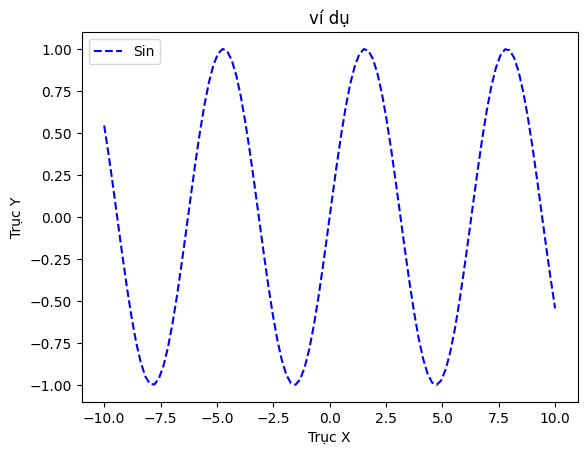

In [13]:
x = np.linspace(-10, 10, 100)
y = np.sin(x)

# Vẽ biểu đồ sin(x)
plt.plot(x, y, label='Sin', color='blue', linestyle='--')
plt.title("ví dụ")
plt.xlabel("Trục X")
plt.ylabel("Trục Y")
plt.legend()
plt.show()

Ta có thể xét ví dụ sau: Cho hàm số $f : D \to \mathbb{R}$ với $D \subseteq \mathbb{R}$ và giả sử $x_0 \in D$ là một điểm trong của $D$. Đạo hàm của $f$ tại $x_0$ là

$$f'(x_0) = \frac{\mathrm{d}f(x_0)}{\mathrm{d}x} = \lim_{h \to 0} \frac{f(x_0 + h) - f(x_0)}{h}$$

với điều kiện giới hạn này tồn tại. Từ định nghĩa này, ta có thể diễn giải ý nghĩa hình học của đạo hàm thông qua đồ thị của hàm số. Cụ thể, đạo hàm của $f$ tại điểm $x_0$ chính là **hệ số góc của đường tiếp tuyến** với đồ thị của hàm số tại điểm $(x_0, f(x_0))$. Trong hình minh họa, điểm màu xanh lam biểu thị vị trí $(x_0, f(x_0))$, và đường thẳng đi qua điểm này là đường tiếp tuyến của đồ thị tại đó. Xét hàm số $f(z) = z^3 - z$



In [14]:
# f(z)
def f(z):
    return z**3 - z

# f'(z)
def df(z):
    return 3*(z**2) - 1

# Điểm để tính tiếp tuyến
x0 = 1.0
y0 = f(x0)
slope = df(x0)

# Tính đường tiếp tuyến
def tangent(z):
    return y0 + slope * (z - x0)



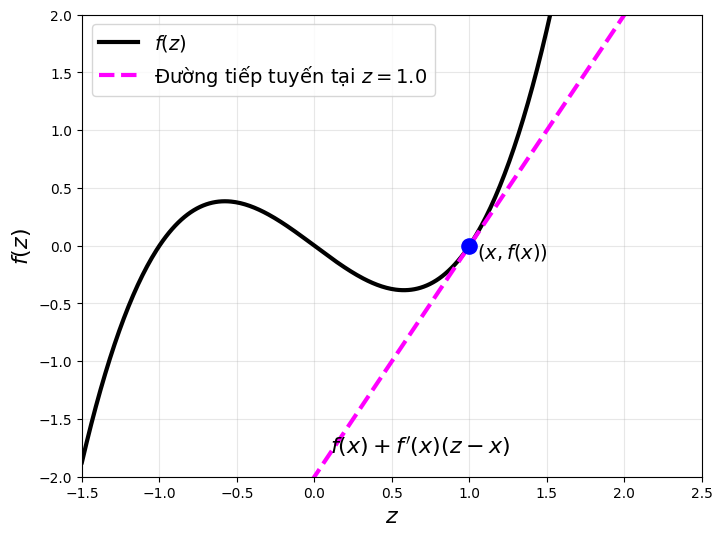

In [15]:
# Tạo mảng giá trị cho trục z
z = np.linspace(-1.5, 2.5, 400)

# Vẽ đồ thị hàm số
plt.figure(figsize=(8,6))
plt.plot(z, f(z), color='black', linewidth=3, label=r'$f(z)$')

# Vẽ Đường tiếp tuyến
plt.plot(z, tangent(z), '--', color='magenta', linewidth=3,
         label=r'Đường tiếp tuyến tại $z=1.0$')

# Đánh dấu điểm tiếp xúc
plt.scatter([x0], [y0], color='blue', s=120, zorder=5)

# Ghi chú cho điểm tiếp xúc
plt.text(x0 + 0.05, y0 - 0.1, '$(x, f(x))$', fontsize=14)

# Ghi chú công thức đường tiếp tuyến
plt.text(0.1, -1.8, r'$f(x) + f^\prime(x)(z - x)$', fontsize=16)

# Nhãn của các trục tọa độ
plt.xlabel(r'$z$', fontsize=16)
plt.ylabel(r'$f(z)$', fontsize=16)

# Giới hạn trục x, y để giống với ảnh minh họa
plt.xlim(-1.5, 2.5)
plt.ylim(-2, 2)

plt.legend(fontsize=14)
plt.grid(alpha=0.3)

plt.show()

Hoặc ta có thể minh họa ma trận nhầm lẫn (Confusion Matrix) bằng `plt`

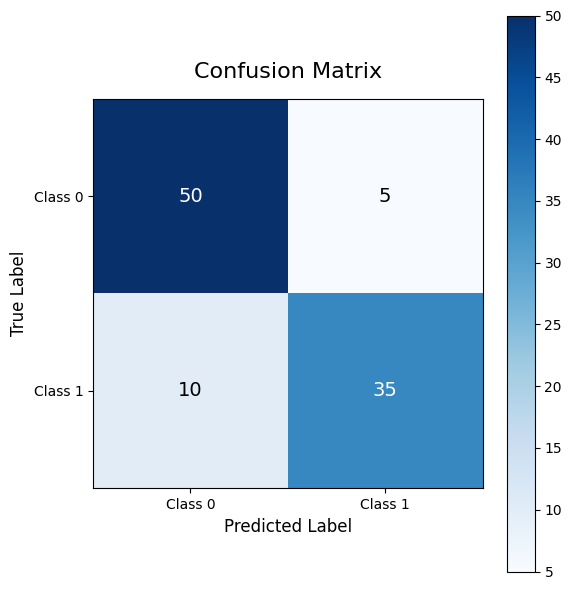

In [16]:
# 1. Tạo dữ liệu giả lập cho Confusion Matrix (ví dụ bài toán phân loại 2 lớp)
# [[True Negative, False Positive],
#  [False Negative, True Positive]]
cm = np.array([[50, 5],
               [10, 35]])

# 2. Khởi tạo biểu đồ
fig, ax = plt.subplots(figsize=(6, 6))

# Vẽ heatmap sử dụng plt.imshow
cax = ax.imshow(cm, cmap='Blues') # cmap='Blues' tạo dải màu xanh dương

# 3. Thêm các con số vào từng ô
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text_color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, str(cm[i, j]), va='center', ha='center',
                color=text_color, fontsize=14)

# 4. Thêm nhãn, tiêu đề và thanh màu
ax.set_title('Confusion Matrix', fontsize=16, pad=15)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)

# Chỉnh tên các lớp (classes) trên trục x và y
classes = ['Class 0', 'Class 1']
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

# Thêm thanh hiển thị dải màu bên cạnh
plt.colorbar(cax)

# Hiển thị
plt.tight_layout()
plt.show()

Ngoài ra, `matplotlib` cũng cho phép ta hiển thị nhiều đồ thị subplots cùng một lúc

In [17]:
iris = sns.load_dataset("iris")

C:\Users\quanp\AppData\Local\Temp\ipykernel_1408\987216849.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=species_counts.index, y=species_counts.values, palette='viridis', ax=axes[1, 1])


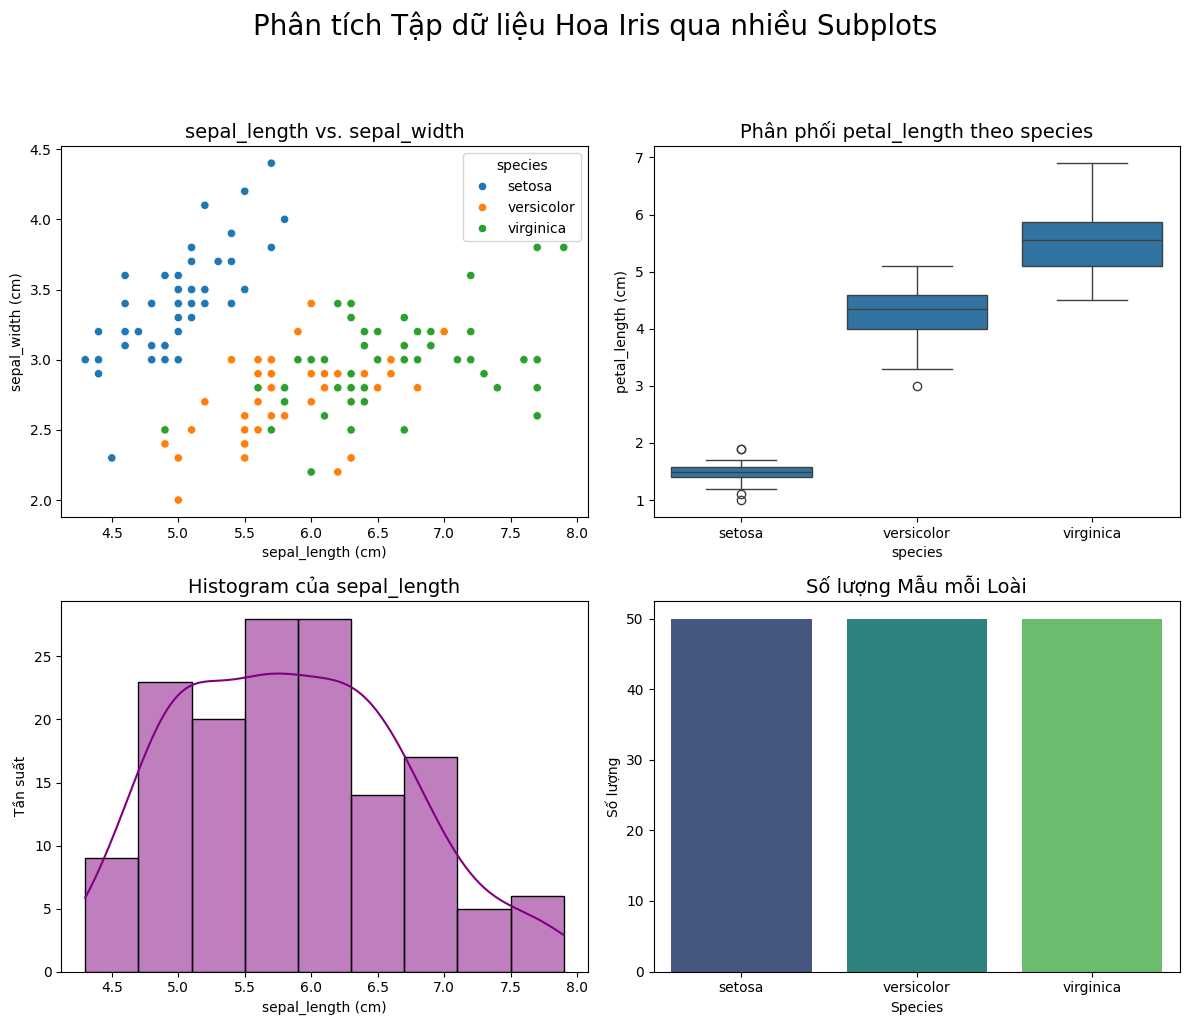

In [18]:
# 2. Tạo Figure và các Axes subplots trong một lưới 2x2
# nrows=2, ncols=2: tạo lưới 2 hàng, 2 cột (tổng cộng 4 ô)
# figsize=(12, 10): thiết lập kích thước tổng thể cho figure
# sharex=False, sharey=False: không chia sẻ trục x, y giữa các biểu đồ
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

# Thiết lập tiêu đề chung cho toàn bộ Figure
plt.suptitle('Phân tích Tập dữ liệu Hoa Iris qua nhiều Subplots', fontsize=20, y=1.02)

# --- Subplot 1 (Ô [0, 0]): Scatter Plot ---
# So sánh mối quan hệ giữa chiều dài đài hoa (sepal_length) và chiều rộng đài hoa (sepal_width)
sns.scatterplot(data=iris, x='sepal_length', y='sepal_width', hue='species', ax=axes[0, 0])
axes[0, 0].set_title('sepal_length vs. sepal_width', fontsize=14)
axes[0, 0].set_xlabel('sepal_length (cm)')
axes[0, 0].set_ylabel('sepal_width (cm)')

# --- Subplot 2 (Ô [0, 1]): Box Plot ---
# Phân phối chiều dài cánh hoa (petal_length) theo từng loài
sns.boxplot(data=iris, x='species', y='petal_length', ax=axes[0, 1])
axes[0, 1].set_title('Phân phối petal_length theo species', fontsize=14)
axes[0, 1].set_xlabel('species')
axes[0, 1].set_ylabel('petal_length (cm)')

# --- Subplot 3 (Ô [1, 0]): Histogram ---
# Phân phối tần suất của chiều dài đài hoa (sepal_length)
sns.histplot(data=iris, x='sepal_length', kde=True, color='purple', ax=axes[1, 0])
axes[1, 0].set_title('Histogram của sepal_length', fontsize=14)
axes[1, 0].set_xlabel('sepal_length (cm)')
axes[1, 0].set_ylabel('Tần suất')

# --- Subplot 4 (Ô [1, 1]): Barplot ---
# Số lượng mẫu cho mỗi loài hoa
species_counts = iris['species'].value_counts()
sns.barplot(x=species_counts.index, y=species_counts.values, palette='viridis', ax=axes[1, 1])
axes[1, 1].set_title('Số lượng Mẫu mỗi Loài', fontsize=14)
axes[1, 1].set_xlabel('Species')
axes[1, 1].set_ylabel('Số lượng')

# 3. Tùy chỉnh khoảng cách giữa các subplot để không bị đè chữ
plt.tight_layout(rect=[0, 0, 1, 0.97])

# Hiển thị biểu đồ
plt.show()

# III. Bài tập

## 1. Lưu ý

Deadline:
- Bài nộp tại lớp sẽ được thêm 0.5 điểm cộng.
- **20h00 - 26/03/2026**

Yêu cầu:
- Có thể sử dụng IDE cá nhân hoặc các platform như Google Colab / Kaggle
- Tạo 1 file notebook (.ipynb) theo cấu trúc : 23XXYYYZZZ_NguyenVanA_PPSTKHDL_BTH01.ipynb
- Trình bày gọn gàng, không copy paste bài của nhau.
- Được phép sử dụng các package, không nhất thiết phải tự code tay tất cả. Được dùng AI nhưng không nên lạm dụng AI
- Nếu có phần giải thích code hoặc kết quả thì càng tốt. Phần này (nếu có) nên được trình bay trong một text cell. Sử dụng Comment "#" cũng được nhưng nên xuống dòng hợp lý.


## 2. Bài tập

### Phần I. Numpy

**Câu 1:** Cho hai vector $\mathbf{u} = [1, 2, 3]$ và $\mathbf{v} = [4, -5, 6]$.

- Yêu cầu: Viết ít nhất 2 cách code khác nhau trong NumPy để tính tích vô hướng của hai vector này và in kết quả ra màn hình.

---
**Câu 2:** Cho hai ma trận $A$ và $B$:$$A = \begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix}, \quad B = \begin{bmatrix} 2 & 0 \\ 1 & 2 \end{bmatrix}$$
- Yêu cầu 1: Viết code tính tích từng phần tử (element-wise multiplication) của $A$ và $B$.

- Yêu cầu 2: Viết code tính tích ma trận (matrix multiplication) của $A$ và $B$.

---
**Câu 3:** Cho hệ phương trình sau: $$2x_1 + 3x_2 - x_3 = 5$$ $$x_1 - x_2 + 2x_3 = 6$$ $$3x_1 + 2x_2 + x_3 = 7$$Yêu cầu: Khởi tạo ma trận hệ số và vector hằng số bằng NumPy. Sau đó, viết code sử dụng module np.linalg để tìm và in ra vector nghiệm $\mathbf{x} = [x_1, x_2, x_3]^T$.

---
**Câu 4**: Cho ma trận vuông $M$:$$M = \begin{bmatrix} 4 & 7 \\ 2 & 6 \end{bmatrix}$$

- Yêu cầu 1: Viết code NumPy tính định thức của $M$.

- Yêu cầu 2: Viết code NumPy tính ma trận nghịch đảo $M^{-1}$.

---
**Câu 5**:

- Yêu cầu 1: Khởi tạo một tensor $T$ có shape (2, 4, 3) chứa toàn số 1 (dùng `np.ones`) và một vector $\mu = [1, 2, 3]$. Viết code thực hiện phép trừ $R = T - \mu$.

- Yêu cầu 2: Viết code sử dụng `np.linalg.norm` để tính chuẩn L2 (Euclidean norm) của tensor $R$ vừa tạo. Bạn cần truyền đúng tham số axis sao cho kết quả in ra là một ma trận có shape (2, 4). Tính L2 với axis = 0. Nhận xét về 2 giá trị L2 này đại diện cho điều gì ?

In [19]:
#cau 1
u = np.array([1, 2, 3])
v = np.array([4, -5, 6])

print("cau 1:")
print(np.dot(u , v))
print(np.matmul(u, v))

cau 1:
12
12


In [20]:
#cau 2
print("cau 2:")
A = np.array([[1, 2], [3, 4]])
B = np.array([[2, 0], [1, 2]])
print(A * B)
print(np.dot(A, B))

cau 2:
[[2 0]
 [3 8]]
[[ 4  4]
 [10  8]]


In [21]:
#cau 3
print("cau 3:")
A = np.array([[2, 3, -1], [1, -1, 2], [3, 2, 1]])
B = np.array([5, 6, 7])
print("X = [x1 x2 x3] = ",np.linalg.solve(A, B))

cau 3:
X = [x1 x2 x3] =  [-9.00719925e+15  9.00719925e+15  9.00719925e+15]


In [22]:
#cau 4
print("cau 4:")
M = np.array([[4, 7], [2, 6]])
print(round(np.linalg.det(M)))

cau 4:
10


In [23]:
#cau 5
print("cau 5:")
T = np.ones((2, 4, 3))
mu = np.array([1, 2, 3])
R = T - mu
print("R = T - mu = ")
print(R)
print("Yeu cau 2:")
print("axis = 2 có shape (2,4)")
print(np.linalg.norm(R, axis=2))
print("axis = 0")
print(np.linalg.norm(R, axis=0))

cau 5:
R = T - mu = 
[[[ 0. -1. -2.]
  [ 0. -1. -2.]
  [ 0. -1. -2.]
  [ 0. -1. -2.]]

 [[ 0. -1. -2.]
  [ 0. -1. -2.]
  [ 0. -1. -2.]
  [ 0. -1. -2.]]]
Yeu cau 2:
axis = 2 có shape (2,4)
[[2.23606798 2.23606798 2.23606798 2.23606798]
 [2.23606798 2.23606798 2.23606798 2.23606798]]
axis = 0
[[0.         1.41421356 2.82842712]
 [0.         1.41421356 2.82842712]
 [0.         1.41421356 2.82842712]
 [0.         1.41421356 2.82842712]]


### Ý nghĩa đại diện:
axis = 2: Nếu bạn coi R là một batch gồm 2 ảnh, mỗi ảnh có kích thước 4 x 1 pixel, và mỗi pixel có 3 kênh màu (ví dụ: RGB). Việc lấy chuẩn L2 theo axis=2 chính là tính độ lớn của đặc trưng (feature magnitude) tại từng vị trí độc lập. Nó có thể đại diện cho khoảng cách hoặc sự sai khác (nếu $R$ là ma trận sai số) của từng điểm dữ liệu so với một mốc tham chiếu mu.
axis = 0: thường đại diện cho chiều của Batch (tập hợp các mẫu dữ liệu). Tính L2 norm dọc theo axis=0 có nghĩa là bạn đang đo lường độ lớn tổng hợp của một đặc trưng cụ thể, tại một vị trí cụ thể, xét trên toàn bộ các mẫu (samples) trong batch đó. Phép tính này thường được dùng khi bạn muốn chuẩn hóa dữ liệu (normalization) theo từng feature dọc theo chiều batch.

### Phần II: PLT
**Câu 1**: Tích phân xác định của hàm số $f(x)$ trên đoạn $[a, b]$ đại diện cho diện tích hình phẳng giới hạn bởi đồ thị hàm số, trục hoành và hai đường thẳng $x = a, x = b$.

- Yêu cầu:
    - Định nghĩa hàm số $f(x) = -x^2 + 4x$.
    - Vẽ đồ thị hàm số này trên khoảng $x \in [0, 4]$.
    - Chọn đoạn tích phân là $[1, 3]$. Hãy tô màu phần diện tích nằm dưới đường cong và trên trục hoành trong đoạn này. (Sử dụng `plt.fill_between(x_fill, y_fill, color='...', alpha=0.3`))
    - Thêm chú thích text: $\int_{1}^{3} (-x^2 + 4x) dx$ vào chính giữa vùng được tô màu. (Sử dụng `plt.text`, dấu $\int$ trong latex là \int)

**Câu 2**: Biết Điểm cực đại/cực tiểu cục bộ là nơi đạo hàm bậc nhất bằng 0  ($f'(x) = 0$) và Điểm uốn là nơi đạo hàm bậc hai bằng 0, $f''(x) = 0$.

- Yêu cầu:
    - Xét hàm số bậc ba: $f(x) = x^3 - 3x^2 + 2$.
    - Vẽ đồ thị $f(x)$ trên khoảng $[-1.5, 3.5]$.
    - Đánh dấu các điểm cực trị bằng chấm tròn màu đỏ, và đánh dấu điểm uốn bằng chấm tròn màu xanh lá. ( Dùng `plt.scatter` để vẽ các điểm )

In [24]:
# cau 1
print("Định nghĩa hàm số f(x)")
def f(x):
    return -x**2 + 4*x
x_val = 2
print(f"f({x_val}) = {f(x_val)}")

x_array = np.array([0, 1, 2, 3, 4])
print(f"f({x_array}) = {f(x_array)}")


Định nghĩa hàm số f(x)
f(2) = 4
f([0 1 2 3 4]) = [0 3 4 3 0]


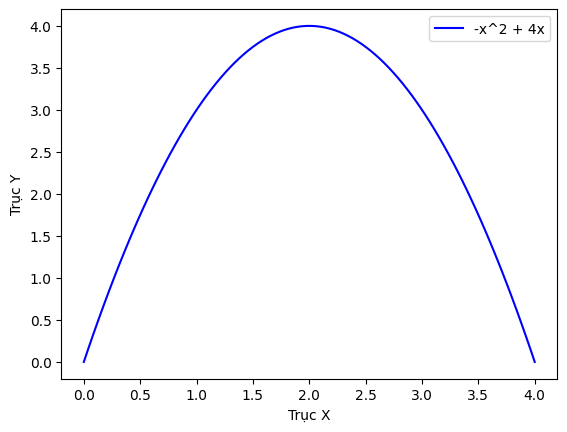

In [25]:
x = np.linspace(0, 4, 100)
plt.plot(x, f(x), label='-x^2 + 4x', color='blue')
plt.xlabel("Trục X")
plt.ylabel("Trục Y")
plt.legend()
plt.show()

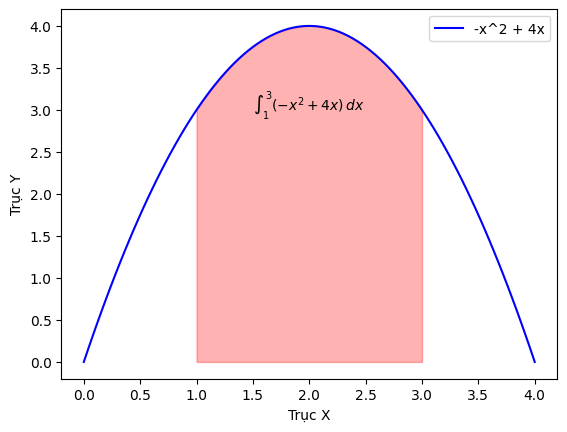

In [26]:
x = np.linspace(0, 4, 100)
plt.plot(x, f(x), label='-x^2 + 4x', color='blue')
plt.xlabel("Trục X")
plt.ylabel("Trục Y")
plt.legend()

x_fill = np.linspace(1, 3, 100)
plt.fill_between(x_fill, f(x_fill), color = 'red', alpha = 0.3)
plt.text(1.5, 3.0, r'$\int_{1}^{3} (-x^2 + 4x) \, dx$')
plt.show()

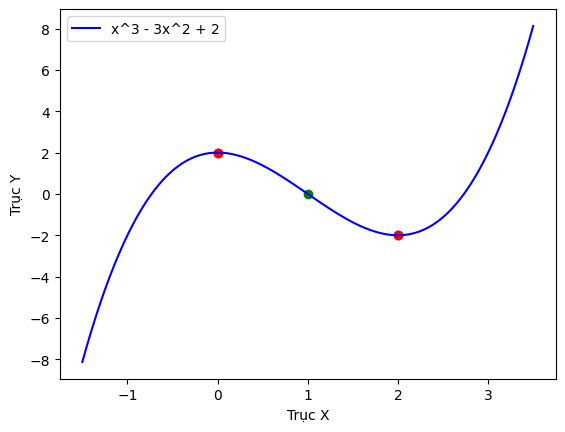

In [27]:
import sympy as sp
#cau 2:
x = sp.Symbol('x')
f = x**3 - 3*x**2 + 2

f1 = sp.diff(f, x)
f2 = sp.diff(f1, x)

x_cuc_tri = sp.solve(f1 , x)
x_diem_uon = sp.solve(f2 , x)

y_cuc_tri = [f.subs(x, val) for val in x_cuc_tri]
y_diem_uon = [f.subs(x, val) for val in x_diem_uon]

def f(x):
    return x**3 - 3*x**2 + 2
x = np.linspace(-1.5, 3.5, 100)
plt.plot(x, f(x), label='x^3 - 3x^2 + 2', color='blue')
plt.xlabel("Trục X")
plt.ylabel("Trục Y")
plt.legend()

for i in range(len(x_cuc_tri)):
    plt.scatter(x_cuc_tri, y_cuc_tri, color = 'red')

for i in range(len(x_diem_uon)):
    plt.scatter(x_diem_uon, y_diem_uon, color = 'green')
plt.show()